In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import pearsonr
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
median = pd.read_csv("Median_sale_price.csv")
pct_above = pd.read_csv("Percent_of_homes_sold_above_list.csv")
rent = pd.read_csv("Zori_median_rent.csv")
market_heat = pd.read_csv("Market_heat.csv")
affordability = pd.read_csv("Affordability_years_to_save.csv")
sale_list = pd.read_csv("Mean_sale_to_list_ratio.csv")
new_cons_sale_price = pd.read_csv("New_con_median_sale_price.csv")

In [ ]:
# Inspect the structure of each dataset before merging to check they have the same columns
raw_datasets = {
    "Median Sale Price": median,
    "Pct Sold Above List": pct_above,
    "Median Rent": rent,
    "Market Heat Index": market_heat,
    "Years to Save": affordability,
    "Sale-to-List Ratio": sale_list,
    "New Construction Sale Price": new_cons_sale_price,
}

for name, df in raw_datasets.items():
    print(f"\n{name} -> shape: {df.shape}")
    print("First columns:", df.columns[:6].tolist())
    print(df.head(3))


Median Sale Price -> shape: (311, 211)
First columns: ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', '2008-02-29']
   RegionID  SizeRank       RegionName RegionType StateName  2008-02-29  \
0    102001         0    United States    country       NaN    170800.0   
1    394913         1     New York, NY        msa        NY    399136.0   
2    753899         2  Los Angeles, CA        msa        CA    470000.0   

   2008-03-31  2008-04-30  2008-05-31  2008-06-30  ...  2024-06-30  \
0    175500.0    177500.0    180000.0    185000.0  ...    368000.0   
1    390000.0    390000.0    392500.0    400000.0  ...    642000.0   
2    455000.0    457000.0    440000.0    435000.0  ...    960000.0   

   2024-07-31  2024-08-31  2024-09-30  2024-10-31  2024-11-30  2024-12-31  \
0    360000.0    359000.0    350000.0    351250.0    350000.0    350000.0   
1    650000.0    645000.0    630000.0    625000.0    625000.0    620000.0   
2    950000.0    932500.0    915000.0    940000.0   

In [ ]:
# Define a melt function
def melt_df(df, value_name):
    date_columns = df.columns[5:]
    melted = df.melt(
        id_vars=["RegionID", "RegionName", "RegionType", "StateName"],
        value_vars=date_columns,
        var_name="Date",
        value_name=value_name
    )
    melted["Date"] = pd.to_datetime(melted["Date"])
    return melted

median_melted = melt_df(median, "MedianSalePrice")
pct_melted = melt_df(pct_above, "PctSoldAboveList")
rent_melted = melt_df(rent, "MedianRent")
market_heat_melted = melt_df(market_heat, "MarketHeatIndex")
affordability_melted = melt_df(affordability, "YearsToSave")
sale_list_melted = melt_df(sale_list, "SaleToListRatio")
new_cons_sale_price_melted = melt_df(new_cons_sale_price, "NewConMedianSalePrice")

In [ ]:
merged = median_melted.copy()
merged = merged.merge(pct_melted, on=["RegionID", "RegionName", "RegionType", "StateName", "Date"])
merged = merged.merge(rent_melted, on=["RegionID", "RegionName", "RegionType", "StateName", "Date"])
merged = merged.merge(market_heat_melted, on=["RegionID", "RegionName", "RegionType", "StateName", "Date"])
merged = merged.merge(affordability_melted, on=["RegionID", "RegionName", "RegionType", "StateName", "Date"])
merged = merged.merge(sale_list_melted, on=["RegionID", "RegionName", "RegionType", "StateName", "Date"])
merged = merged.merge(new_cons_sale_price_melted, on=["RegionID", "RegionName", "RegionType", "StateName", "Date"])

print(merged.head())

   RegionID       RegionName RegionType StateName       Date  MedianSalePrice  \
0    102001    United States    country       NaN 2018-03-31         224719.0   
1    394913     New York, NY        msa        NY 2018-03-31         380000.0   
2    753899  Los Angeles, CA        msa        CA 2018-03-31         620000.0   
3    394463      Chicago, IL        msa        IL 2018-03-31         220000.0   
4    394514       Dallas, TX        msa        TX 2018-03-31         259000.0   

   PctSoldAboveList   MedianRent  MarketHeatIndex  YearsToSave  \
0          0.227457  1381.671080             53.0     7.355010   
1          0.201962  2451.857818             55.0    11.960819   
2          0.401445  2181.502665             66.0    17.404722   
3          0.157976  1568.020649             51.0     6.487640   
4          0.275308  1296.265759             59.0     6.979034   

   SaleToListRatio  NewConMedianSalePrice  
0         0.978256               321281.0  
1         0.975797          

Shape: (10500, 12)

Column Types:
 RegionID                          int64
RegionName                       object
RegionType                       object
StateName                        object
Date                     datetime64[ns]
MedianSalePrice                 float64
PctSoldAboveList                float64
MedianRent                      float64
MarketHeatIndex                 float64
YearsToSave                     float64
SaleToListRatio                 float64
NewConMedianSalePrice           float64
dtype: object

Missing values per column:
 NewConMedianSalePrice    1718
PctSoldAboveList          301
SaleToListRatio           291
MedianRent                191
StateName                  84
dtype: int64


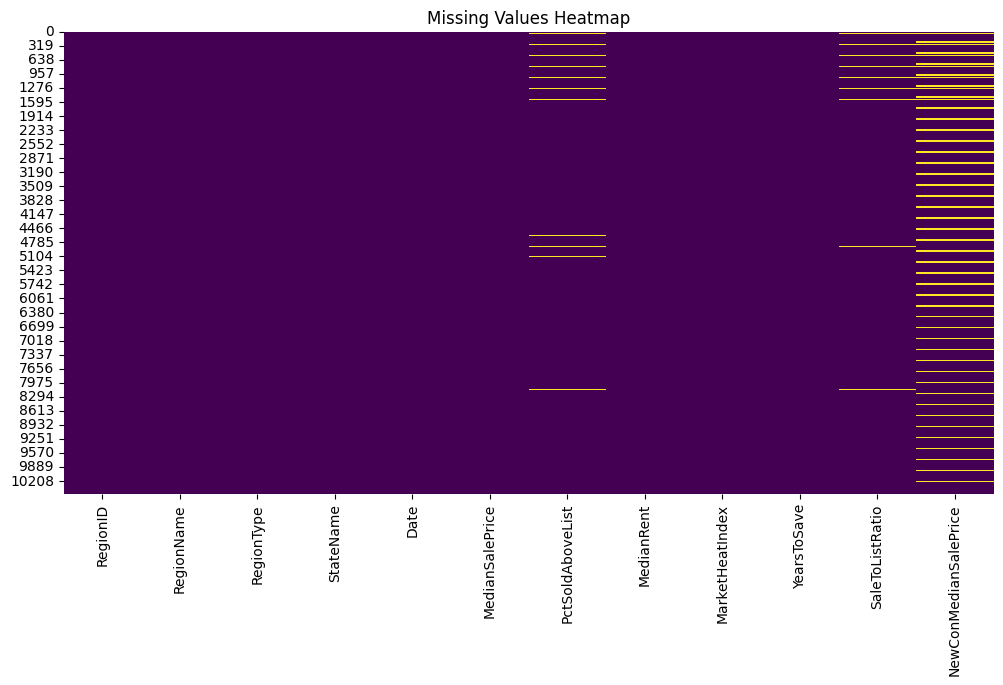

In [ ]:
print("Shape:", merged.shape)

print("\nColumn Types:\n", merged.dtypes)

missing_values = merged.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("\nMissing values per column:\n", missing_values)

plt.figure(figsize=(12, 6))
sns.heatmap(merged.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
# Drop rows with missing values (not NewConMedianSalePrice)
core_columns = ["PctSoldAboveList", "SaleToListRatio", "MedianRent", "StateName"]
merged_cleaned = merged.dropna(subset=core_columns)

print("\nRows before drop:", merged.shape[0])
print("Rows after drop (excluding only key variables):", merged_cleaned.shape[0])

print("\nDuplicate Rows:", merged.duplicated().sum())


Rows before drop: 10500
Rows after drop (excluding only key variables): 9893

Duplicate Rows: 0


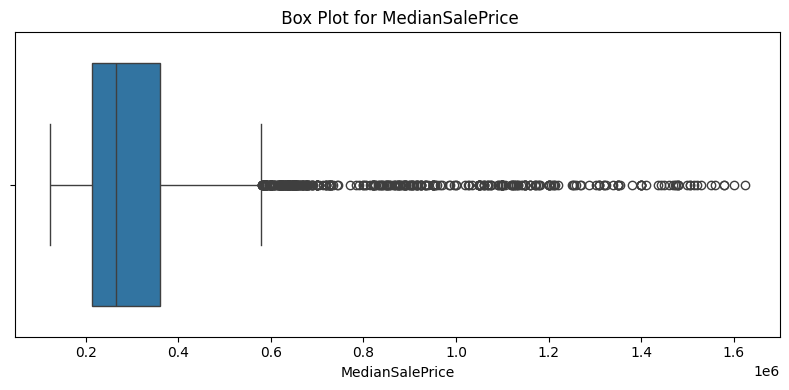

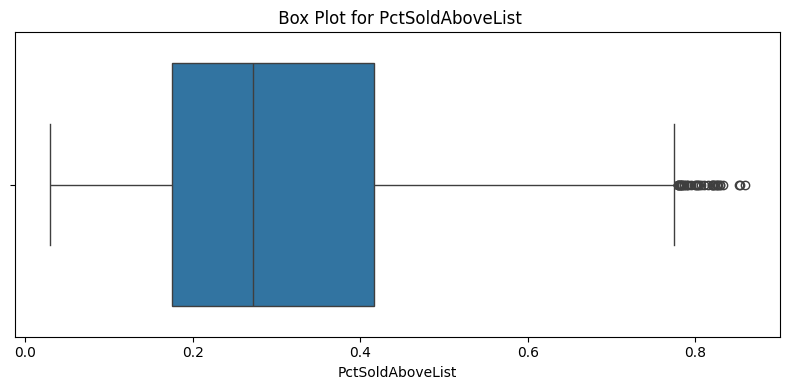

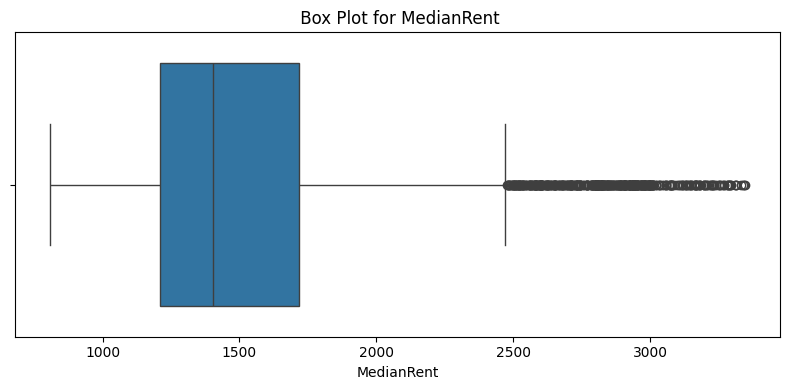

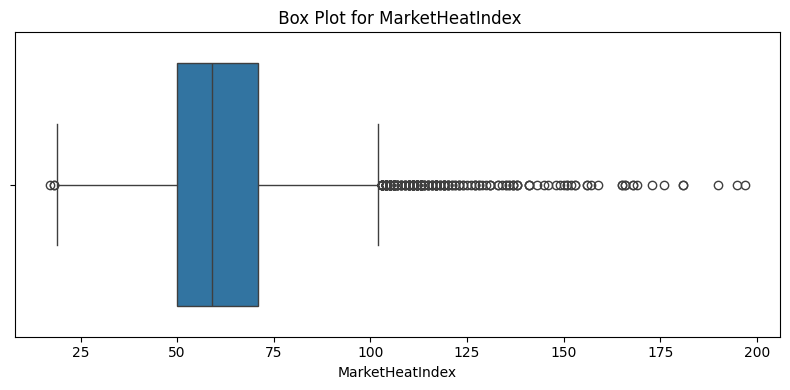

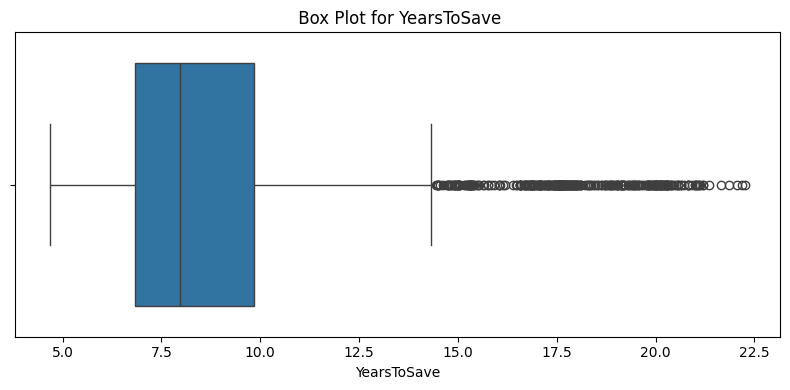

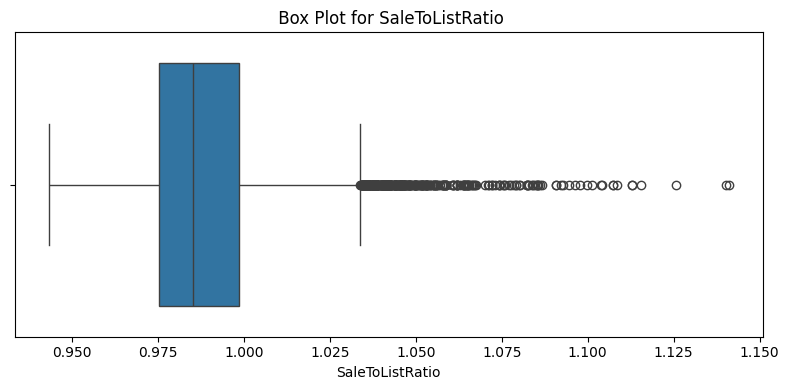

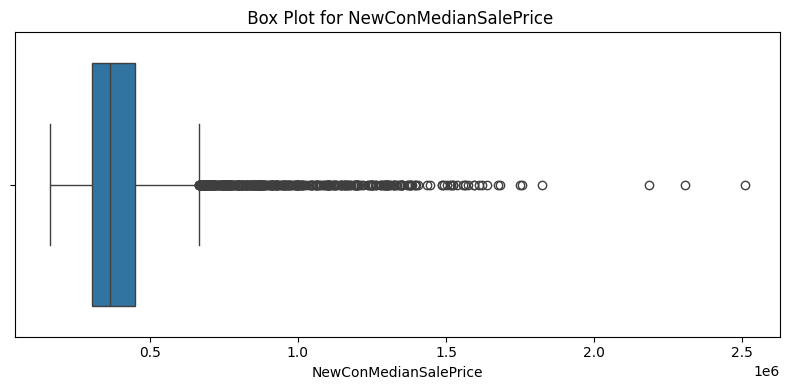

In [ ]:
numeric_cols = merged_cleaned.select_dtypes(include=['float64', 'int64']).drop(columns=["RegionID"])

for col in numeric_cols.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=merged_cleaned[col])
    plt.title(f' Box Plot for {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [ ]:
# Descriptive Statistics
desc_stats = merged_cleaned.describe()
print(desc_stats)

            RegionID                           Date  MedianSalePrice  \
count    9893.000000                           9893     9.893000e+03   
mean   406601.992621  2021-10-16 19:09:28.038006528     3.096715e+05   
min    394312.000000            2018-03-31 00:00:00     1.219750e+05   
25%    394531.000000            2020-01-31 00:00:00     2.131770e+05   
50%    394792.000000            2021-10-31 00:00:00     2.650000e+05   
75%    395005.000000            2023-07-31 00:00:00     3.599000e+05   
max    753912.000000            2025-02-28 00:00:00     1.625000e+06   
std     64112.991749                            NaN     1.627796e+05   

       PctSoldAboveList   MedianRent  MarketHeatIndex  YearsToSave  \
count       9893.000000  9893.000000      9893.000000  9893.000000   
mean           0.306217  1500.371539        61.627211     8.631004   
min            0.029102   806.913837        17.000000     4.670567   
25%            0.175565  1208.192870        50.000000     6.822396   
5

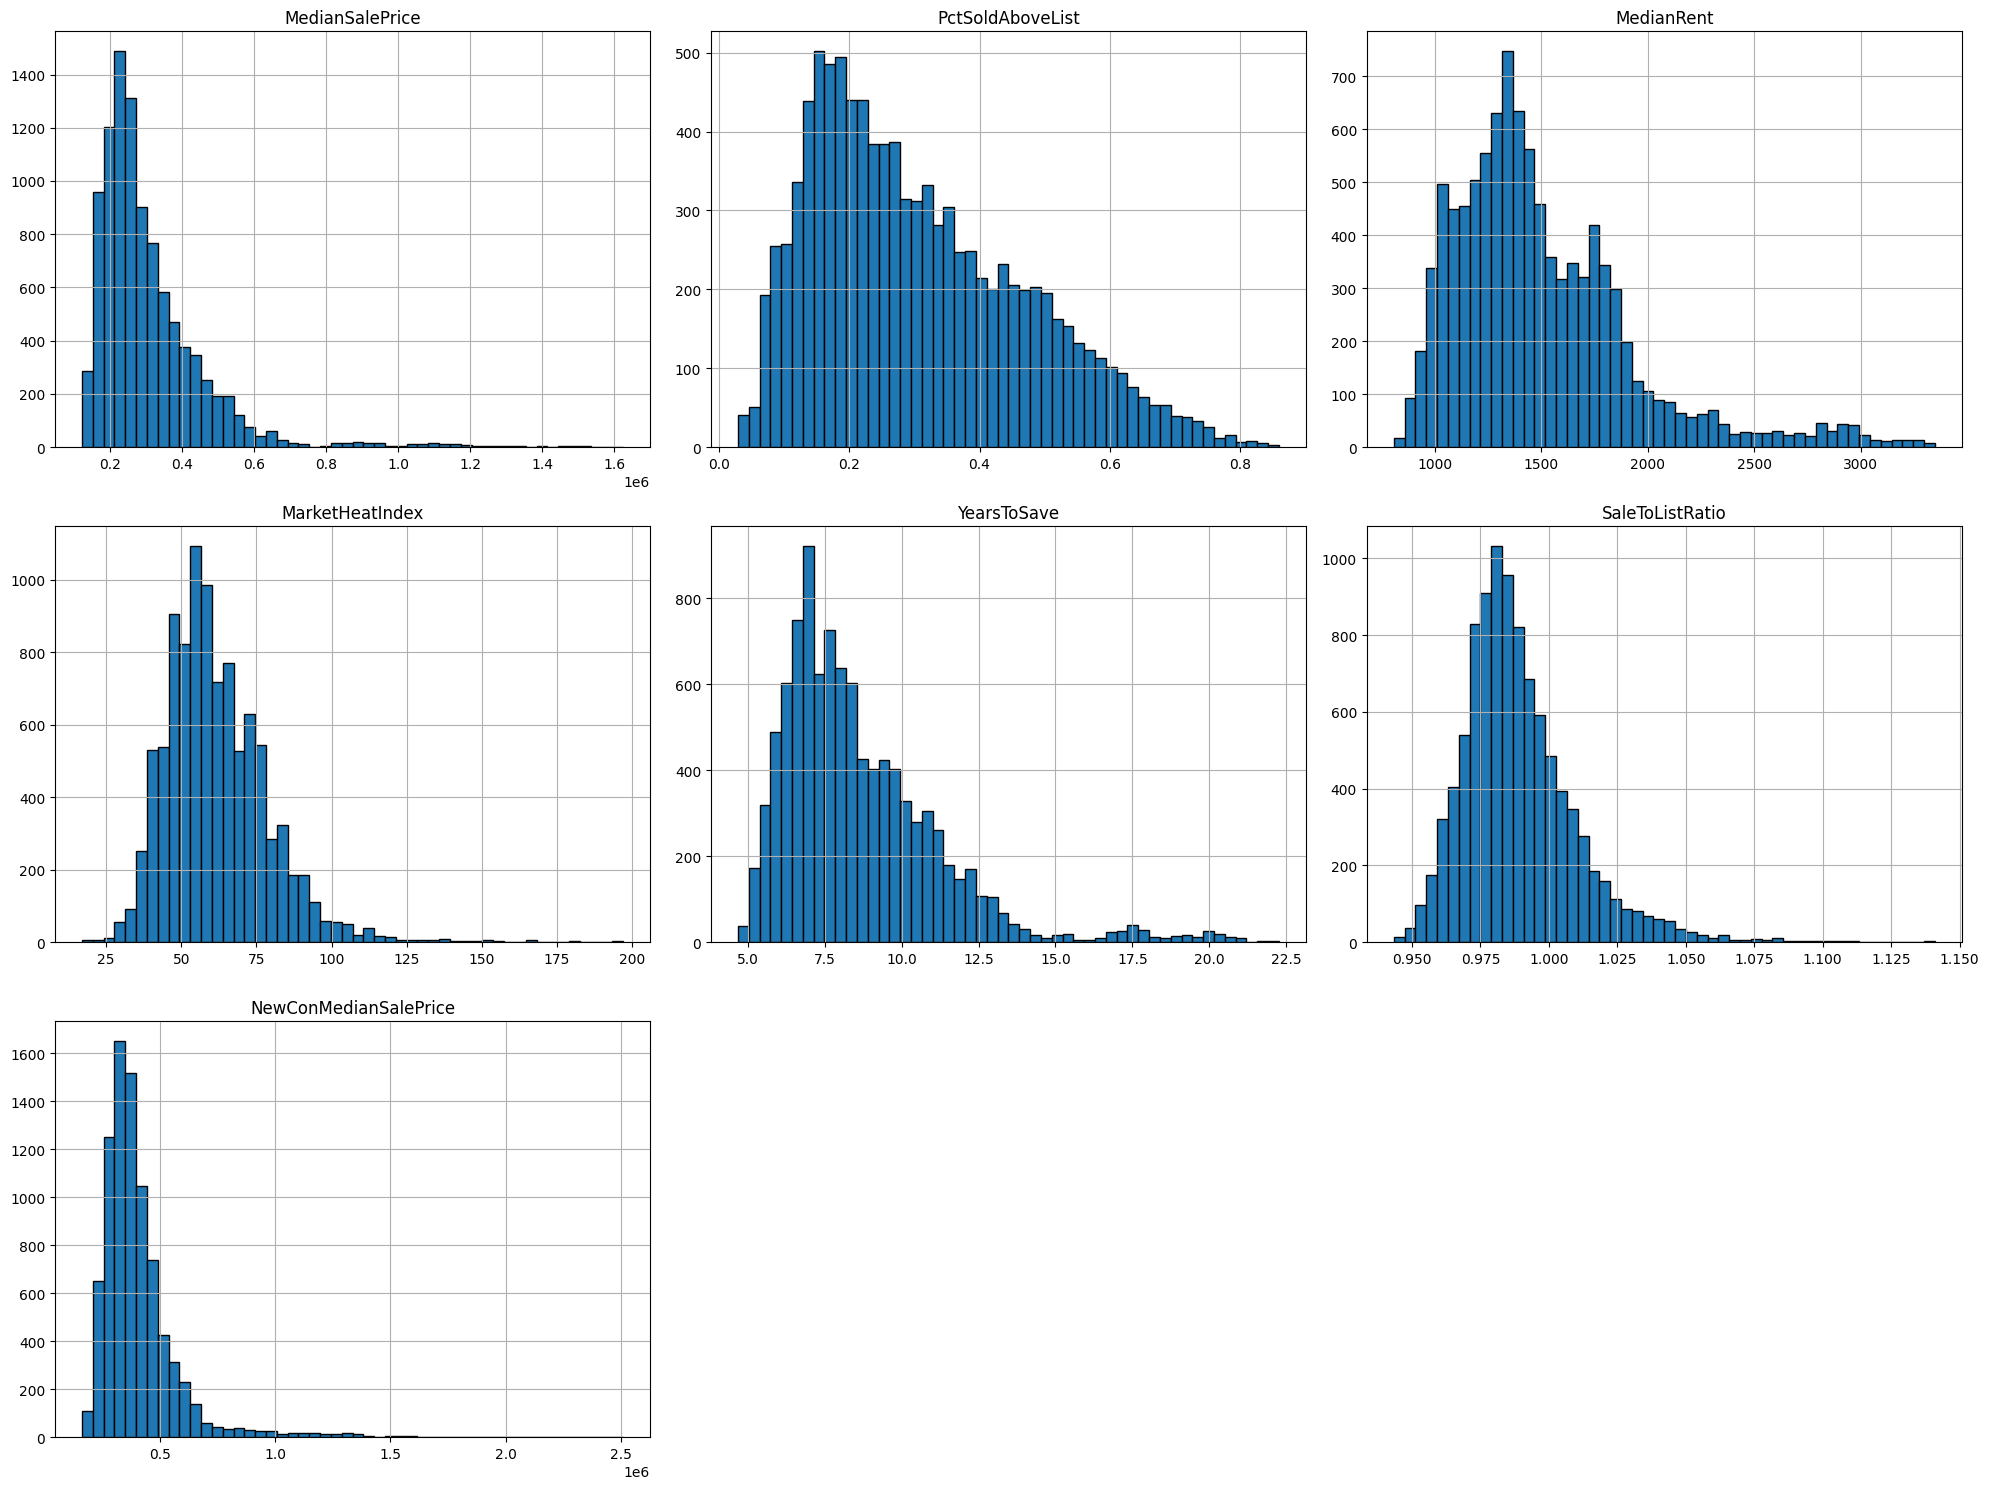

In [ ]:
# Histogram for numeric columns
numeric_cols = merged_cleaned.select_dtypes(include=['float64', 'int64']).drop(columns=["RegionID"])

numeric_cols.hist(bins=50, figsize=(20, 15), edgecolor='black')
plt.tight_layout()
plt.show()

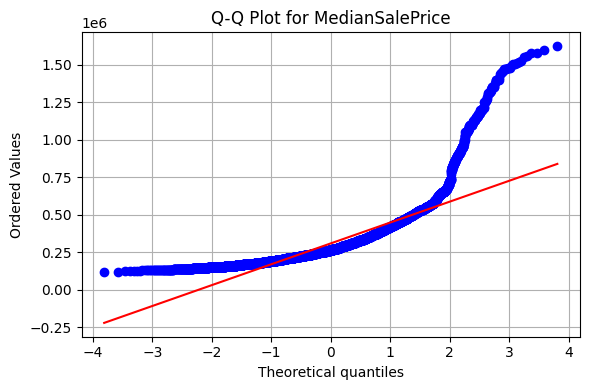

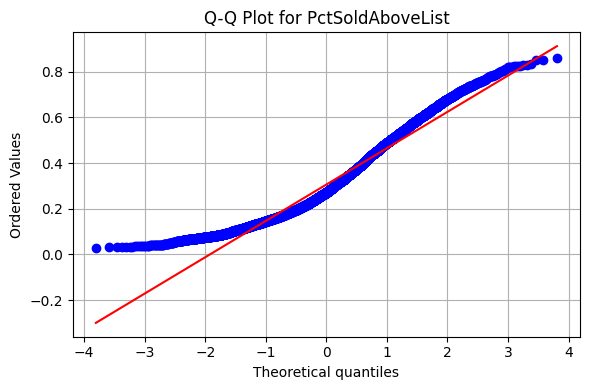

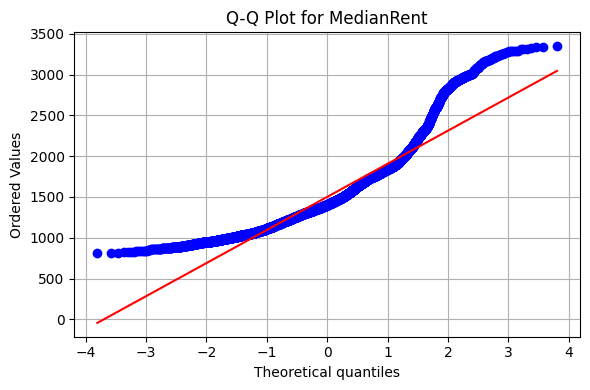

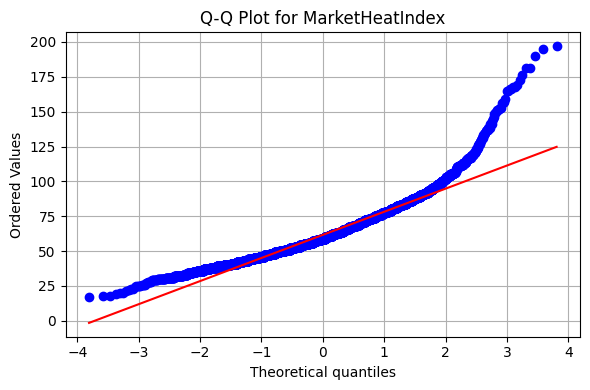

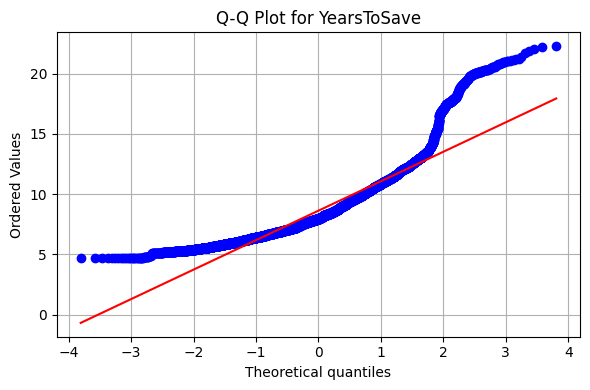

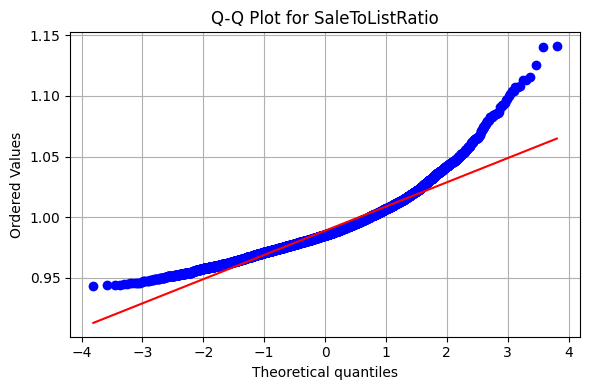

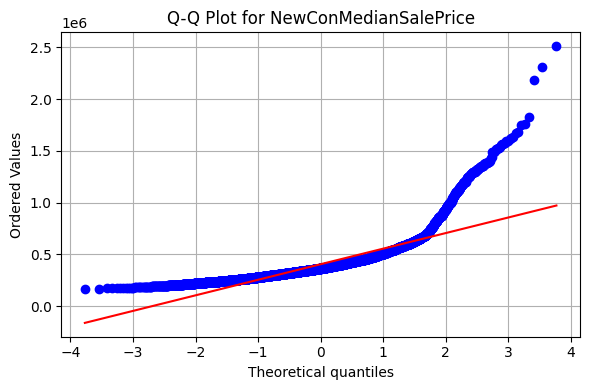

In [ ]:
# Plot Q-Q plots
for col in numeric_cols.columns:
    plt.figure(figsize=(6, 4))
    stats.probplot(numeric_cols[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot for {col}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

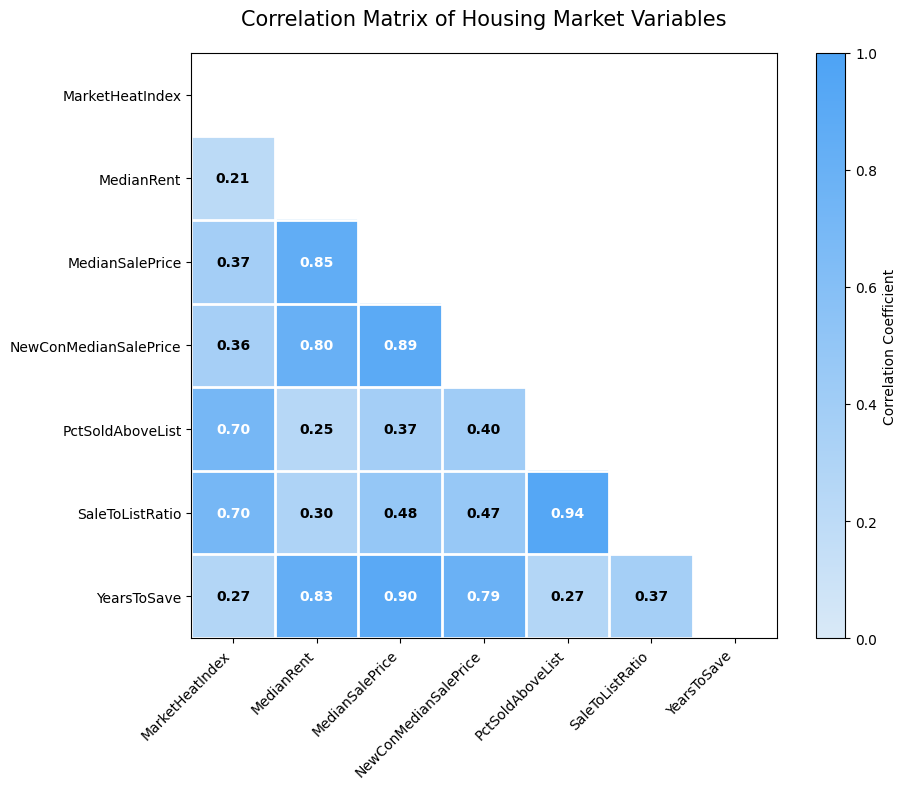

In [ ]:
# Correlation matrix
cols = [
    "MarketHeatIndex",
    "MedianRent",
    "MedianSalePrice",
    "NewConMedianSalePrice",
    "PctSoldAboveList",
    "SaleToListRatio",
    "YearsToSave",
]

corr = merged_cleaned[cols].corr()

blue_scale = LinearSegmentedColormap.from_list("blue_scale", ["#d9e9f7", "#4da3f5"])

mask = np.triu(np.ones_like(corr, dtype=bool))
corr_plot = corr.copy()
corr_plot[mask] = np.nan

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_plot, cmap=blue_scale, vmin=0, vmax=1)

ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        if not np.isnan(corr_plot.iloc[i, j]):
            value = corr_plot.iloc[i, j]

            text_color = "white" if value > 0.65 else "black"
            ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                    fontsize=10, fontweight="bold", color=text_color)

ax.set_xticks(np.arange(-.5, len(cols), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(cols), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)


cbar = plt.colorbar(im)
cbar.set_label("Correlation Coefficient")

plt.title("Correlation Matrix of Housing Market Variables", fontsize=15, pad=20)

plt.tight_layout()

plt.savefig("correlation_matrix_thesis.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from scipy.stats import pearsonr

# Pearson correlation tests for the key relationships
subset_corr = merged_cleaned[['MedianSalePrice', 'NewConMedianSalePrice']].dropna()
r1, p1 = pearsonr(subset_corr['MedianSalePrice'], subset_corr['NewConMedianSalePrice'])
print("Correlation between Median Sale Price and NewConMedianSalePrice:")
print(f"Pearson r = {r1:.2f} | p-value = {p1:.4f}")

subset_corr = merged_cleaned[['MedianSalePrice', 'SaleToListRatio']].dropna()
r1, p1 = pearsonr(subset_corr['MedianSalePrice'], subset_corr['SaleToListRatio'])
print("\nCorrelation between Median Sale Price and SaleToListRatio:")
print(f"Pearson r = {r1:.2f} | p-value = {p1:.4f}")

subset_corr = merged_cleaned[['MarketHeatIndex', 'PctSoldAboveList']].dropna()
r1, p1 = pearsonr(subset_corr['MarketHeatIndex'], subset_corr['PctSoldAboveList'])
print("\nCorrelation between MarketHeatIndex and PctSoldAboveList:")
print(f"Pearson r = {r1:.2f} | p-value = {p1:.4f}")

Correlation between Median Sale Price and NewConMedianSalePrice:
Pearson r = 0.89 | p-value = 0.0000

Correlation between Median Sale Price and SaleToListRatio:
Pearson r = 0.48 | p-value = 0.0000

Correlation between MarketHeatIndex and PctSoldAboveList:
Pearson r = 0.70 | p-value = 0.0000


/tmp/ipykernel_6534/594934141.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_cleaned["Date"] = pd.to_datetime(merged_cleaned["Date"])


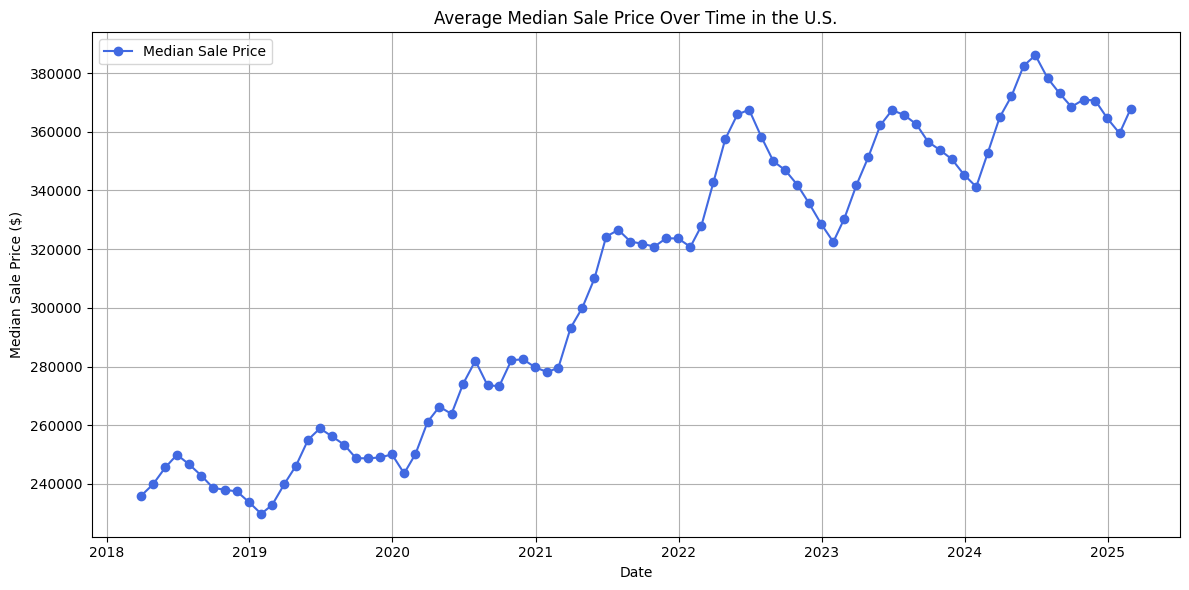

In [ ]:
# Time Series Plot: Average median sale price over time
merged_cleaned["Date"] = pd.to_datetime(merged_cleaned["Date"])

price_trend = merged_cleaned.groupby("Date")["MedianSalePrice"].mean()

plt.figure(figsize=(12, 6))
plt.plot(price_trend.index, price_trend.values, marker='o', label="Median Sale Price", color='royalblue')
plt.title("Average Median Sale Price Over Time in the U.S.")
plt.xlabel("Date")
plt.ylabel("Median Sale Price ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

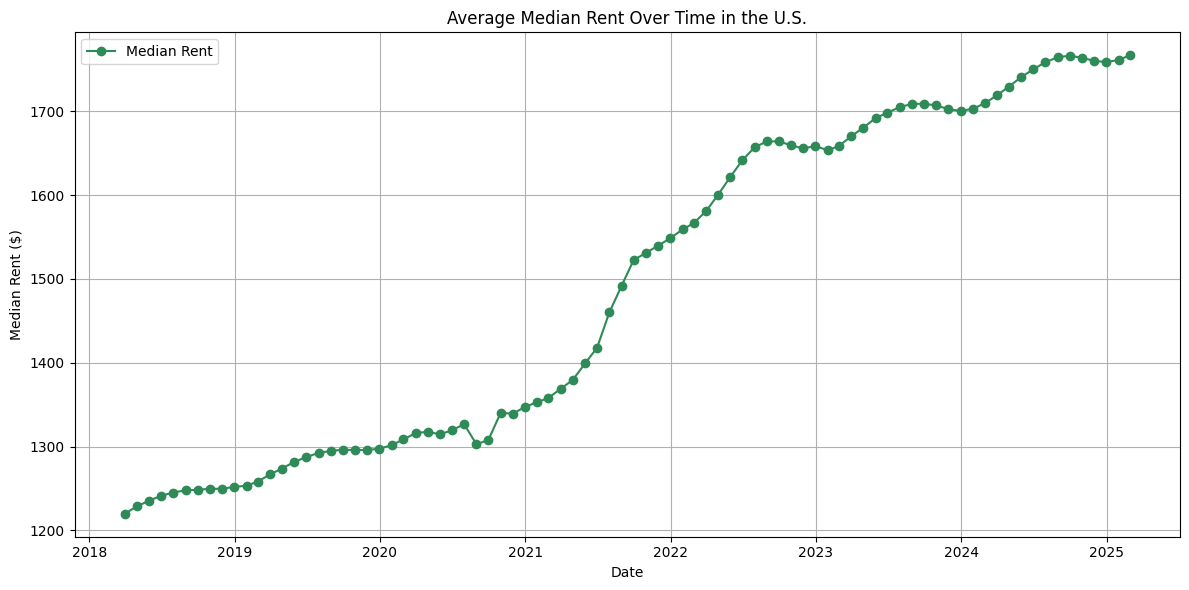

In [ ]:
# Average median rent over time
rent_trend = merged_cleaned.groupby("Date")["MedianRent"].mean()

plt.figure(figsize=(12, 6))
plt.plot(rent_trend.index, rent_trend.values, marker='o', label="Median Rent", color='seagreen')
plt.title("Average Median Rent Over Time in the U.S.")
plt.xlabel("Date")
plt.ylabel("Median Rent ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

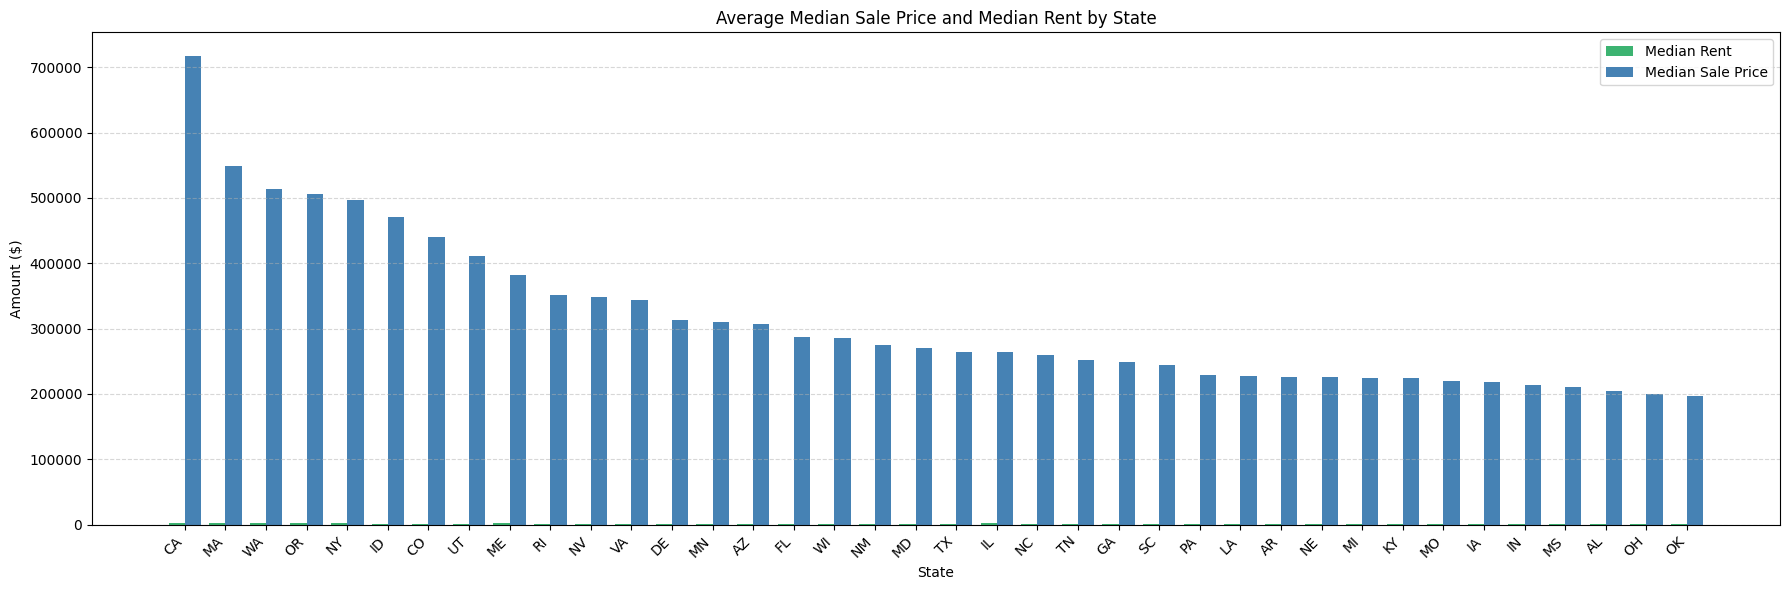

In [ ]:
# Average sale price and rent by state, sorted by median sale price
state_group = merged_cleaned.groupby("StateName")[["MedianSalePrice", "MedianRent"]].mean()

state_group = state_group.sort_values("MedianSalePrice", ascending=False)

plt.figure(figsize=(18, 6))
bar_width = 0.4
states = state_group.index
x = range(len(states))

plt.bar([i for i in x], state_group["MedianRent"], width=bar_width, label="Median Rent", color="mediumseagreen", zorder=2)

plt.bar([i + bar_width for i in x], state_group["MedianSalePrice"], width=bar_width, label="Median Sale Price", color="steelblue", zorder=1)

plt.xlabel("State")
plt.ylabel("Amount ($)")
plt.title("Average Median Sale Price and Median Rent by State")
plt.xticks([i + bar_width / 2 for i in x], states, rotation=45, ha='right')
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

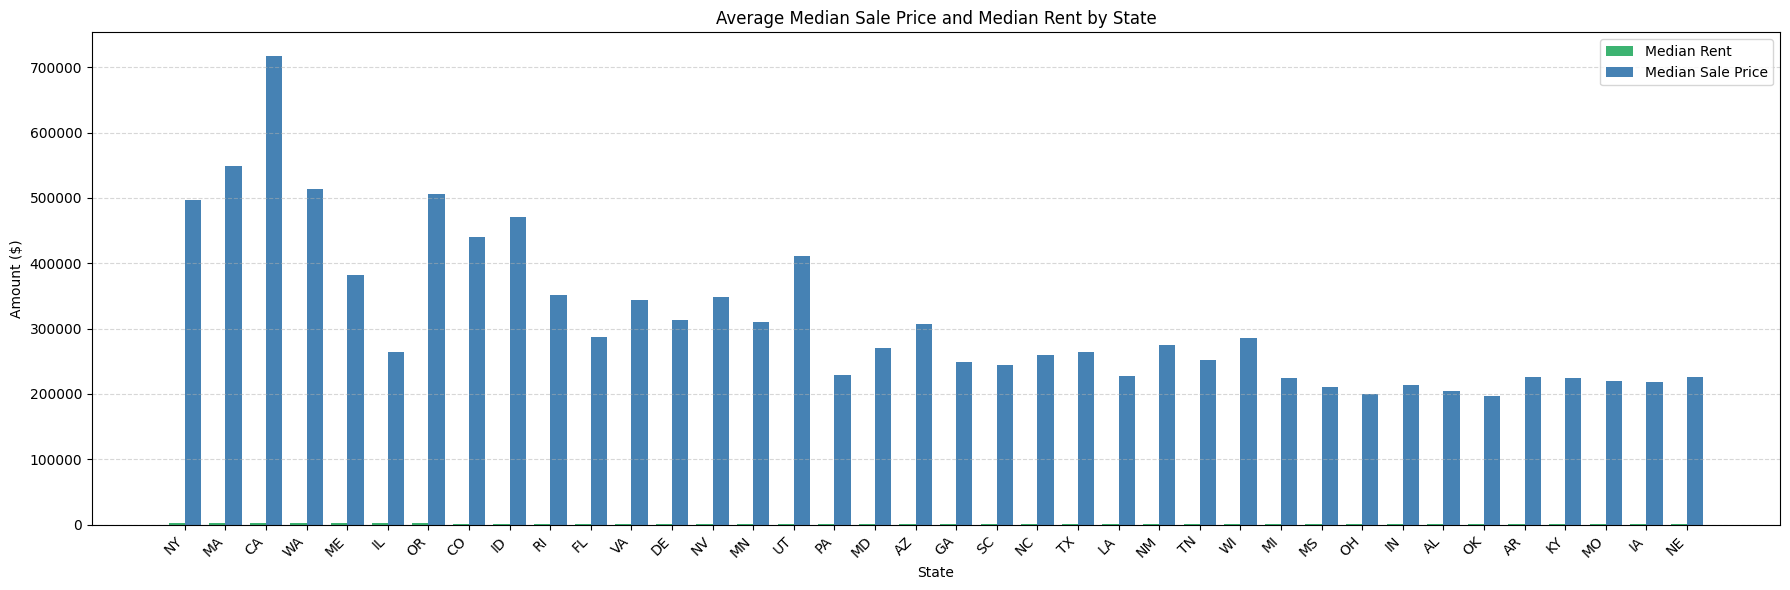

In [ ]:
# Average sale price and rent by state, sorted by median rent
state_group = merged_cleaned.groupby("StateName")[["MedianSalePrice", "MedianRent"]].mean()

state_group = state_group.sort_values("MedianRent", ascending=False)

plt.figure(figsize=(18, 6))
bar_width = 0.4
states = state_group.index
x = range(len(states))

plt.bar([i for i in x], state_group["MedianRent"], width=bar_width, label="Median Rent", color="mediumseagreen", zorder=2)

plt.bar([i + bar_width for i in x], state_group["MedianSalePrice"], width=bar_width, label="Median Sale Price", color="steelblue", zorder=1)

plt.xlabel("State")
plt.ylabel("Amount ($)")
plt.title("Average Median Sale Price and Median Rent by State")
plt.xticks([i + bar_width / 2 for i in x], states, rotation=45, ha='right')
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

In [ ]:
merged_cleaned.to_csv("merged_cleaned.csv", index=False)